In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =======FILE UPLOAD WIDGET=======
upload_btn = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload License Plate Image',
    layout=widgets.Layout(width='250px', height='100px')
)

output = widgets.Output()
image = None
uploaded_filename = None

def on_upload_change(change):
    global image, uploaded_filename
    with output:
        clear_output(wait=True)
        
        # Check if files were uploaded
        if len(upload_btn.value) > 0:
            # Get the first uploaded file (it's a Bunch object)
            uploaded_file = upload_btn.value[0]
            
            # Access content from the Bunch (it's like a dictionary)
            if 'content' in uploaded_file:
                # Get the memory object and convert to bytes
                memory_view = uploaded_file['content']
                content = bytes(memory_view)  # Convert memory to bytes
                uploaded_filename = uploaded_file.get('name', 'unknown.jpg')
                
                # Convert bytes to image
                nparr = np.frombuffer(content, np.uint8)
                image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
                
                if image is not None:
                    # Save to file (overwrites each time)
                    cv2.imwrite('temp_image.jpg', image)
                    
                    print(f"\nUploaded: {uploaded_filename}\n")
                    
                    # Show preview
                    plt.figure(figsize=(8,4))
                    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                    plt.title('Ready to Process!')
                    plt.axis('off')
                    plt.show()
                else:
                    print("Failed to decode image")
            else:
                print("No content found in uploaded file")
        else:
            print("Click the upload button to select an image")

# Connect the function
upload_btn.observe(on_upload_change, names='value')

# Display the widget
display(upload_btn, output)

FileUpload(value=(), accept='image/*', description='Upload License Plate Image', layout=Layout(height='100px',…

Output()

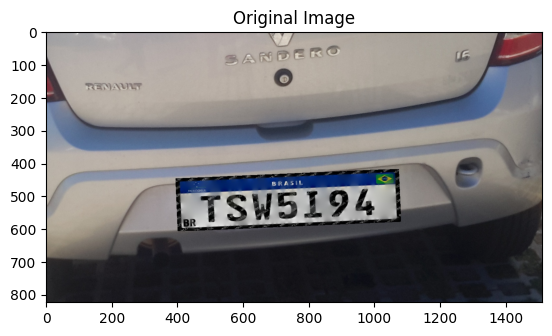

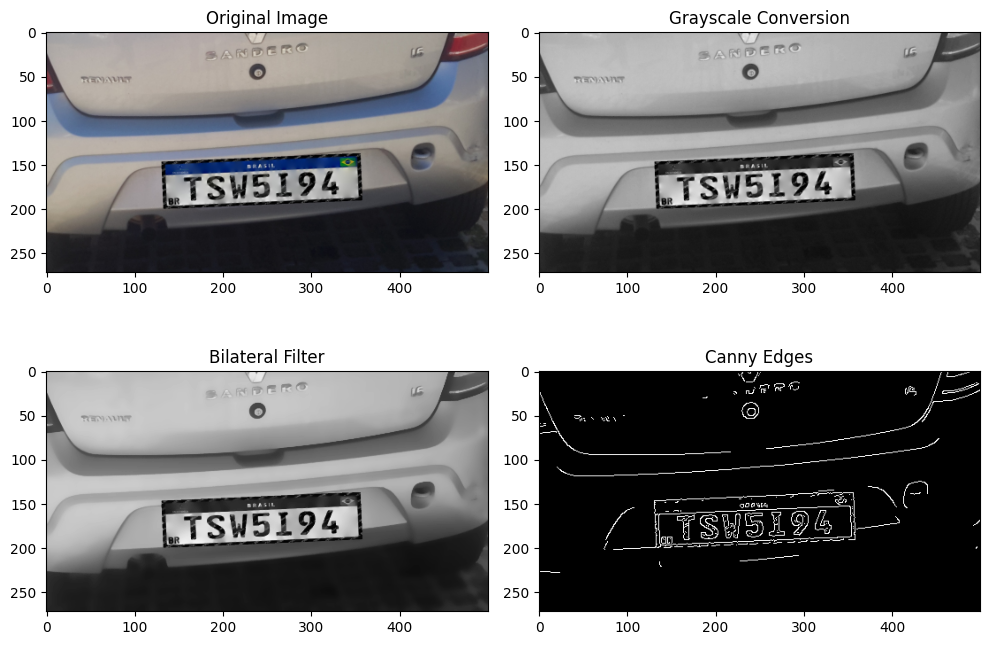

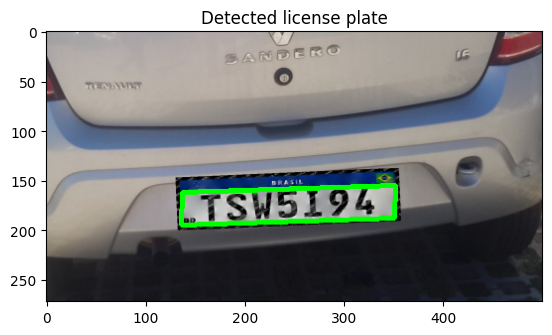

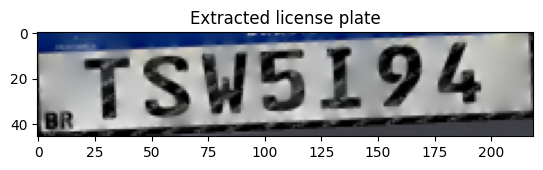

[[[352 155]]

 [[351 188]]

 [[136 195]]

 [[137 162]]]
2 1
136 195 351 188


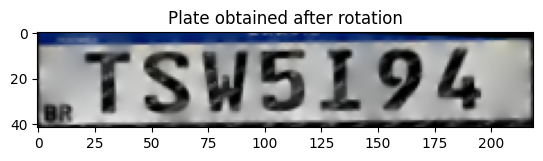

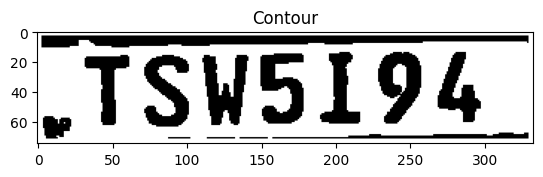

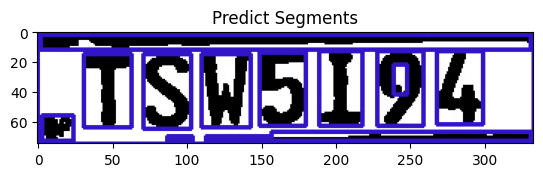

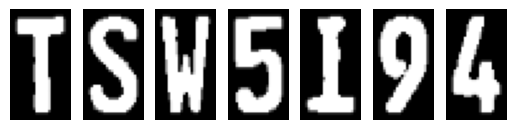

In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import imutils
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
from sklearn.metrics import f1_score

import tensorflow.compat.v1 as tf
import tensorflow.keras.backend as K
from tensorflow.keras import optimizers

from keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Input, Dropout
from keras.models import Model, Sequential
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam

# ===== DATABASE SETUP =====
import sqlite3
from datetime import datetime
import pandas as pd

global conn, cursor
conn = sqlite3.connect('license_plates.db')
cursor = conn.cursor()

# Create table if it doesn't exist
cursor.execute('''CREATE TABLE IF NOT EXISTS plates 
             (id INTEGER PRIMARY KEY AUTOINCREMENT,
              plate TEXT NOT NULL,
              timestamp DATETIME NOT NULL,
              image_file TEXT)''')
conn.commit()

# Variable to track current session plates (for display)
session_plates = []

# Read the uploaded image file
# the function imread() returns a numpy array containing the image
image = cv2.imread('temp_image.jpg')
if image is None:
    print("Please upload an image first using the widget above!")
#img = cv2.imread('dumb.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

image = imutils.resize(image, width=500)
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the original image
fig, ax = plt.subplots(2, 2, figsize=(10,7))
ax[0,0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0,0].set_title('Original Image')

# RGB to Gray scale conversion
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ax[0,1].imshow(gray, cmap='gray')
ax[0,1].set_title('Grayscale Conversion')

# Noise removal with iterative bilateral filter (removes noise while preserving edges)
gray = cv2.bilateralFilter(gray, 11, 17, 17)
ax[1,0].imshow(gray, cmap='gray')
ax[1,0].set_title('Bilateral Filter')

# Find the edges of the grayscale image
edged = cv2.Canny(gray, 170, 200)
ax[1,1].imshow(edged, cmap='gray')
ax[1,1].set_title('Canny Edges')

fig.tight_layout()
plt.show()

# Find contours based on edges (sharp changes in image intensity)
cnts = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)[0]
cnts = sorted(cnts, key = cv2.contourArea, reverse = True)[:30]   #Sort contours based on their area keeping minimum required area as '30' (anything smaller than this will not be considered)
NumberPlateCnt = None

# Look for the first contour in our top 30 that, when simplified, has exactly 4 corners
count = 0
for c in cnts:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:   #Select the contour with 4 corners
            NumberPlateCnt = approx   #This is our approx Number Plate Contour
            x,y,w,h = cv2.boundingRect(c)
            ROI = img[y:y+h, x:x+w]
            break

if NumberPlateCnt is not None:
    # Drawing the selected (GREEN) contour on the original image
    cv2.drawContours(image, [NumberPlateCnt], -1, (0,255,0), 3)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Detected license plate")
plt.show()

# Find bounding box and extract ROI
plt.imshow(ROI)
plt.title("Extracted license plate")
plt.show()

print(NumberPlateCnt)

# Function that calculates the Euclidean distance between two points
def dist(x1, x2, y1, y2):
    return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5

idx = 0
m = 0
# Find the corner with the largest y-coordinate (the "lowest point of the image")
for i in range(4):
    if NumberPlateCnt[i][0][1] > m:
        idx = i
        m = NumberPlateCnt[i][0][1]

    # Get the index of the PREVIOUS corner in the contour list
    if idx == 0:
        pin = 3
    else:
        pin = idx - 1
    
    # Get the index of the NEXT corner
    if idx == 3:
        nin = 0
    else:
        nin = idx + 1

# Calculate distances from the lowest point to its two adjacent corners
p = dist(NumberPlateCnt[idx][0][0], NumberPlateCnt[pin][0][0], NumberPlateCnt[idx][0][1], NumberPlateCnt[pin][0][1])
n = dist(NumberPlateCnt[idx][0][0], NumberPlateCnt[nin][0][0], NumberPlateCnt[idx][0][1], NumberPlateCnt[nin][0][1])

# The two bottom corners of the plate should be the farthest apart horizontally

# Determine the two bottom corners of the polygon in correct left-right order
if p > n:
    if NumberPlateCnt[pin][0][0] < NumberPlateCnt[idx][0][0]:
        left = pin
        right = idx
    else:
        left = idx
        right = pin
    d = p
else:
    if NumberPlateCnt[nin][0][0] < NumberPlateCnt[idx][0][0]:
        left = nin
        right = idx
    else:
        left = idx
        right = nin
    d = n
print(left, right)

left_x = NumberPlateCnt[left][0][0]
left_y = NumberPlateCnt[left][0][1]
right_x = NumberPlateCnt[right][0][0]
right_y = NumberPlateCnt[right][0][1]
print(left_x, left_y, right_x, right_y)

# Finding the angle of rotation by calculating sin of theta
opp = right_y - left_y   # Vertical difference between bottom corners
hyp = ((left_x - right_x) ** 2 + (left_y - right_y) ** 2) ** 0.5   # Distance between bottom corners
sin = opp / hyp
theta = math.asin(sin) * 57.2958   # Convert radians to degrees (57.2958 ≈ 180/π)

# Rotate the image according to the angle of rotation obtained
image_center = tuple(np.array(ROI.shape[1::-1]) / 2)
rot_mat = cv2.getRotationMatrix2D(image_center, theta, 1.0)
result = cv2.warpAffine(ROI, rot_mat, ROI.shape[1::-1], flags = cv2.INTER_LINEAR)

# The image can be cropped after rotation (since a rotated image takes much more height)
# Calculate how much to crop
if opp > 0:
    h = result.shape[0] - opp // 2
else:
    h = result.shape[0] + opp // 2

result=result[0:h, :]    # Remove the unnecessary blank areas
plt.imshow(result)
plt.title("Plate obtained after rotation")
plt.show()

# Match contours to license plate or character template
def find_contours(dimensions, img) :

    # Find all contours in the image
    cntrs, _ = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Retrieve potential dimensions
    lower_width = dimensions[0]
    upper_width = dimensions[1]
    lower_height = dimensions[2]
    upper_height = dimensions[3]
    
    # Consider only the top 15 biggest contours
    cntrs = sorted(cntrs, key = cv2.contourArea, reverse = True)[:15]
    
    ii = cv2.imread('contour.jpg')
    
    x_cntr_list = []
    target_contours = []
    img_res = []
    for cntr in cntrs :
        # Detects contour in binary image and returns the coordinates of rectangle enclosing it
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        
        # Checking the dimensions of the contour to filter out the characters by contour's size
        if intWidth > lower_width and intWidth < upper_width and intHeight > lower_height and intHeight < upper_height :
            x_cntr_list.append(intX)   # Stores the x coordinate of the character's contour, to used later for indexing the contours

            char_copy = np.zeros((44,24))
            # Extracting each character using the enclosed rectangle's coordinates.
            char = img[intY:intY+intHeight, intX:intX+intWidth]
            char = cv2.resize(char, (20, 40))

            # Make result formatted for classification: invert colors (from black text on white bg to white text on black bg)
            char = cv2.subtract(255, char)

            # Resize the image to 24x44 with black border padding (framing each char)
            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy)   # List that stores the character's binary image (unsorted)

    # draw the chars on the license plate img
    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        cv2.rectangle(ii, (intX, intY), (intWidth + intX, intY + intHeight), (50,21,200), 2)
    
    # Show the newly drawn img
    plt.imshow(ii, cmap='gray')
    plt.title('Predict Segments')
    plt.show()
            
    # Return characters in ascending order with respect to the x-coordinate (most-left character first)
    # Arbitrary function that stores list of character indeces
    indices = sorted(range(len(x_cntr_list)), key = lambda k: x_cntr_list[k])  # sort the indices based on their corresponding values in x_cntr_list
    img_res_copy = []
    for idx in indices:
        img_res_copy.append(img_res[idx])   # Stores the characters in reading order (left to right)
    img_res = np.array(img_res_copy)

    return img_res

# Find characters in the resulting images
def segment_characters(image) :

    # Preprocess cropped license plate image
    img_lp = cv2.resize(image, (333, 75))
    img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
    
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    # Replaced erode + dilate with morphologyEx - it does the same thing but in one operation ==> faster
    kernel = np.ones((3,3), np.uint8)
    img_binary_lp = cv2.morphologyEx(img_binary_lp, cv2.MORPH_CLOSE, kernel)

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]

    # Make borders white
    img_binary_lp[0:3,:] = 255
    img_binary_lp[:,0:3] = 255
    img_binary_lp[72:75,:] = 255
    img_binary_lp[:,330:333] = 255

    # Estimations of character contours sizes of cropped license plates
    dimensions = [LP_WIDTH / 4,
                  LP_WIDTH / 2,
                  LP_HEIGHT / 10,
                  2 * LP_HEIGHT / 3]
    
    plt.imshow(img_binary_lp, cmap='gray')
    plt.title('Contour')
    plt.show()
    cv2.imwrite('contour.jpg',img_binary_lp)

    # Get contours within cropped license plate
    char_list = find_contours(dimensions, img_binary_lp)

    return char_list

char = segment_characters(result)

# Displays all the segmented characters side-by-side
for i in range(len(char)):
    plt.subplot(1, len(char), i+1)
    plt.imshow(char[i], cmap='gray')
    plt.axis('off')
plt.show()


In [3]:
# Create a new model instance <==> the prediction phase

class LicensePlateRecognizer:
    def __init__(self, weights_path, training_mode, loaded_model_path):
        print("Building model architecture...")
        self.model = self._build_model(training_mode, loaded_model_path)
        self.char_map = {i: c for i, c in enumerate('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ')}
        if not training_mode:
            print("Loading model weights...")
            self.model.load_weights(weights_path)
            print("Model loaded successfully!")
        else:
            print("Training mode: Model built without loading weights")
        
    def _build_model(self, training_mode, loaded_model_path):
        if training_mode:
            model = Sequential()
            model.add(Conv2D(16, (22,22), input_shape=(28, 28, 3), activation='relu', padding='same'))
            model.add(Conv2D(32, (16,16), activation='relu', padding='same'))
            model.add(Conv2D(64, (8,8), activation='relu', padding='same'))
            model.add(Conv2D(64, (4,4), activation='relu', padding='same'))
            model.add(MaxPooling2D(pool_size=(4, 4)))
            model.add(Dropout(0.4))
            model.add(Flatten())
            model.add(Dense(128, activation='relu'))
            model.add(Dense(36, activation='softmax'))
            
            model.compile(loss='sparse_categorical_crossentropy', 
                          optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001), 
                          metrics=['accuracy'])
        else:
            from tensorflow.keras.models import load_model
            model = load_model(loaded_model_path)
    
        return model

    # This fct takes the grayscale image (1 channel) and converts it to a 3-channel image by copying the same values to all RGB channels
    # This is necessary because the CNN model expects 3-channel input, but the segmented characters are grayscale
    def _fix_dimension(self, img):
        new_img = np.zeros((28,28,3))
        for i in range(3):
            new_img[:,:,i] = img
        return new_img
    
    def recognize_character(self, char_img):
        img_ = cv2.resize(char_img, (28,28), interpolation=cv2.INTER_AREA)
        img = self._fix_dimension(img_)
        img = img.reshape(1,28,28,3)
        
        predictions = self.model.predict(img, verbose=0)[0]
        char_idx = np.argmax(predictions)
        
        return self.char_map[char_idx]
    
    def recognize_plate(self, char_images):
        plate_chars = []
        for i, char_img in enumerate(char_images):
            character = self.recognize_character(char_img)
            plate_chars.append(character)
            print(f"Character {i+1}/{len(char_images)}: {character}")
        
        plate_number = ''.join(plate_chars)
        return plate_number

checkpoint_dir = './checkpoints'
checkpoint_path = f'{checkpoint_dir}/my_checkpoint'
full_model_path = f'{checkpoint_dir}/full_model.keras'
os.makedirs(checkpoint_dir, exist_ok=True)
# Training the model - only once though!
if not os.path.exists(f'{checkpoint_path}.index'):
    train_datagen = ImageDataGenerator(rescale=1./255, width_shift_range=0.1, height_shift_range=0.1)
    path = 'data'
    train_generator = train_datagen.flow_from_directory(
            path+'/train',   # Loads all the templates from train dir in data
            target_size=(28,28),   # All images will be resized to 28x28
            batch_size=1,
            class_mode='sparse')
    
    validation_generator = train_datagen.flow_from_directory(
            path + '/val',   # Loads all the templates from val dir in data
            target_size=(28,28),   
            class_mode='sparse')

    recognizer = LicensePlateRecognizer(checkpoint_path, True, full_model_path)
    
    # Epoch reffers to the group of stored templates that is being analyzed
    recognizer.model.fit(
          train_generator,
          steps_per_epoch = train_generator.samples,
          validation_data = validation_generator, 
          epochs = 25, verbose=1, callbacks=None)

    recognizer.model.save_weights(checkpoint_path)
    recognizer.model.save(full_model_path)
    print("Model trained and saved!")
else:
    recognizer = LicensePlateRecognizer(checkpoint_path, False, full_model_path)
    
plate = recognizer.recognize_plate(char)

# ===== SAVE TO DATABASE =====
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Insert into database
cursor.execute("INSERT INTO plates (plate, timestamp, image_file) VALUES (?, ?, ?)",
               (plate, timestamp, uploaded_filename))  # same filename from the widget
conn.commit()

# Add to session list for display
session_plates.append({
    'plate': plate,
    'timestamp': timestamp,
    'image': uploaded_filename
})

print(f"Saved to database License Plate: {plate}")

Found 867 images belonging to 36 classes.
Found 218 images belonging to 36 classes.
Building model architecture...


Training mode: Model built without loading weights
Epoch 1/25


867/867 [==============================] - 12s 13ms/step - loss: 3.2106 - accuracy: 0.1223 - val_loss: 2.0432 - val_accuracy: 0.3670
Epoch 2/25
867/867 [==============================] - 9s 11ms/step - loss: 1.3531 - accuracy: 0.5836 - val_loss: 0.5874 - val_accuracy: 0.8394
Epoch 3/25
867/867 [==============================] - 9s 10ms/step - loss: 0.5817 - accuracy: 0.8120 - val_loss: 0.4697 - val_accuracy: 0.8670
Epoch 4/25
867/867 [==============================] - 9s 10ms/step - loss: 0.3786 - accuracy: 0.8720 - val_loss: 0.2710 - val_accuracy: 0.9220
Epoch 5/25
867/867 [==============================] - 9s 10ms/step - loss: 0.2521 - accuracy: 0.9239 - val_loss: 0.2060 - val_accuracy: 0.9358
Epoch 6/25
867/867 [==============================] - 9s 11ms/step - loss: 0.2684 - accuracy: 0.9043 - val_loss: 0

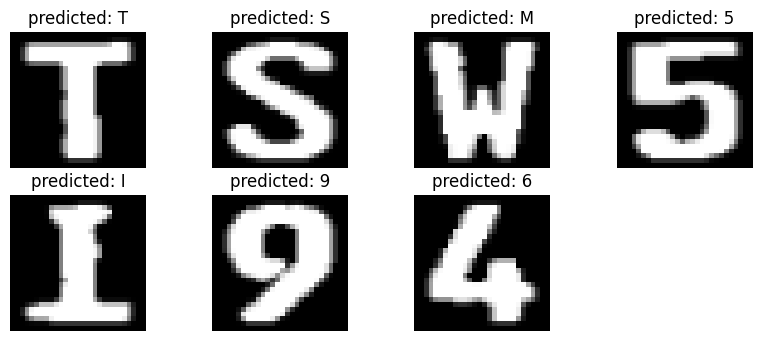

In [4]:
# Segmented characters and their predicted value.
plt.figure(figsize=(10,6))
for i,ch in enumerate(char):
    img = cv2.resize(ch, (28,28), interpolation=cv2.INTER_AREA)
    plt.subplot(3,4,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(f'predicted: {plate[i]}')
    plt.axis('off')
plt.show()

In [5]:
# ===== VIEW DATABASE =====
print("\n" + "="*20 + "ALL PLATES IN DATABASE" + "="*20)

# Query all plates
df = pd.read_sql_query("SELECT * FROM plates ORDER BY timestamp DESC", conn)
print(f"{'ID':<4} {'PLATE':<10} {'TIMESTAMP':<20} {'IMAGE':<30}")
print("-" * 64)
for _, row in df.iterrows():
    print(f"{row['id']:<4} {row['plate']:<10} {row['timestamp']:<20} {row['image_file']:<30}")

# Show session summary
print(f"\nThis session ({len(session_plates)} plates):")
for p in session_plates:
    print(f"  • {p['plate']} - {p['timestamp']}")

# Close connection when done (optional - keeps file locked)
# conn.close()


====================ALL PLATES IN DATABASE====================
ID   PLATE      TIMESTAMP            IMAGE                         
----------------------------------------------------------------
2    TSM5I96    2026-02-27 20:16:58  cropped_parking_lot_65.JPG    
1    A0AAJ16    2026-02-27 20:00:00  cropped_parking_lot_8.JPG     

This session (1 plates):
  • TSM5I96 - 2026-02-27 20:16:58
